# BirdCLEF 2026 — Model Analysis

This notebook covers three analyses:
1. **Results visualisation** — learning curves, val_AUC across seeds, 5s vs 10s comparison
2. **Per-class analysis** — AUC distribution per species across models
3. **Attention visualisation** — Transformer attention maps on example spectrograms

All metrics are loaded from the `metrics_*.jsonl` files and model checkpoints in the output directory.

In [1]:
import subprocess
import sys
import os

os.environ['PYTHONPATH'] = (
    '/home/renku/work/.venv/lib/python3.11/site-packages:' 
    + os.environ.get('PYTHONPATH', '')
)

subprocess.run([
    'pip', 'install',
    'torch==2.6.0+cu124',
    'torchvision==0.21.0+cu124', 
    'torchaudio==2.6.0+cu124',
    '--index-url', 'https://download.pytorch.org/whl/cu124',
    '--force-reinstall', '--no-cache-dir'
], check=True)

# Restart the kernel after this cell completes
print('Done — restart the kernel now before running other cells')

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 269.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 241.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 268.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 268.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 239.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 235.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 243.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 236.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 226.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 210.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [1]:
import torch
print(torch.__version__)         # 2.6.0+cu124
print(torch.cuda.is_available()) # True

2.11.0+cu130
False


/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import torch
import sys

# ── Paths ──────────────────────────────────────────────────
REPO_ROOT   = Path('/home/renku/work/aml2026-group-10')
OUTPUT_DIR  = Path('/home/renku/work/kaggle-data/aml2026-group10-runs')
DATA_ROOT   = Path('/home/renku/work/aml2026-group-10/birdclef_stash')

sys.path.insert(0, str(REPO_ROOT))

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Paths configured.')
print(f'Output dir exists: {OUTPUT_DIR.exists()}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Paths configured.
Output dir exists: True
Using device: cpu


---
## 1. Results Visualisation
### 1.1 Load metrics from .jsonl files

In [3]:
def load_jsonl(path):
    """Load a .jsonl file into a list of dicts. Returns [] if file not found."""
    path = Path(path)
    if not path.exists():
        print(f'  WARNING: {path.name} not found — skipping.')
        return []
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

def get_field(rows, field, default=float('nan')):
    return [r.get(field, default) for r in rows]

# ── Load all 5s metrics ───────────────────────────────────────────────────────
# Adjust tag suffixes to match your actual filenames in OUTPUT_DIR
metrics = {
    'RF Baseline':              load_jsonl(OUTPUT_DIR / 'metrics_rf_baseline.jsonl'),
    'ViT (scratch) s42':        load_jsonl(OUTPUT_DIR / 'metrics_vit_baseline_vit_baseline_v1.jsonl'),
    'ViT (scratch) s123':       load_jsonl(OUTPUT_DIR / 'metrics_vit_baseline__final_seed123.jsonl'),
    'ViT (scratch) s456':       load_jsonl(OUTPUT_DIR / 'metrics_vit_baseline__final_seed456.jsonl'),
    'CNN Baseline s42':         load_jsonl(OUTPUT_DIR / 'metrics_cnn_baseline__final_seed42.jsonl'),
    'CNN Baseline s123':        load_jsonl(OUTPUT_DIR / 'metrics_cnn_baseline__final_seed123.jsonl'),
    'CNN Baseline s456':        load_jsonl(OUTPUT_DIR / 'metrics_cnn_baseline__final_seed456.jsonl'),
    'CNN-Transformer s42':      load_jsonl(OUTPUT_DIR / 'metrics_cnn_transformer_final_seed42.jsonl'),
    'CNN-Transformer s123':     load_jsonl(OUTPUT_DIR / 'metrics_cnn_transformer_final_seed123.jsonl'),
    'CNN-Transformer s456':     load_jsonl(OUTPUT_DIR / 'metrics_cnn_transformer_final_seed456.jsonl'),
    'Pretrained ViT s42':       load_jsonl(OUTPUT_DIR / 'metrics_pretrained_transformer__final_seed42.jsonl'),
    'Pretrained ViT s123':      load_jsonl(OUTPUT_DIR / 'metrics_pretrained_transformer__final_seed123.jsonl'),
    'Pretrained ViT s456':      load_jsonl(OUTPUT_DIR / 'metrics_pretrained_transformer__final_seed456.jsonl'),
}

# ── Load 10s metrics ──────────────────────────────────────────────────────────
metrics_10s = {
    'CNN Baseline 10s':         load_jsonl(OUTPUT_DIR / 'metrics_cnn_baseline__10s_seed42.jsonl'),
    'CNN-Transformer 10s':      load_jsonl(OUTPUT_DIR / 'metrics_cnn_transformer__10s_seed42.jsonl'),
    'ViT (scratch) 10s':        load_jsonl(OUTPUT_DIR / 'metrics_vit_baseline__10s_seed42.jsonl'),
    'Pretrained ViT 10s':       load_jsonl(OUTPUT_DIR / 'metrics_pretrained_transformer_10s_seed42.jsonl'),
}

loaded = {k: v for k, v in {**metrics, **metrics_10s}.items() if v}
print(f'Loaded {len(loaded)} metrics files:')
for k, v in loaded.items():
    print(f'  {k}: {len(v)} epochs')

Loaded 17 metrics files:
  RF Baseline: 1 epochs
  ViT (scratch) s42: 30 epochs
  ViT (scratch) s123: 15 epochs
  ViT (scratch) s456: 15 epochs
  CNN Baseline s42: 15 epochs
  CNN Baseline s123: 15 epochs
  CNN Baseline s456: 15 epochs
  CNN-Transformer s42: 15 epochs
  CNN-Transformer s123: 15 epochs
  CNN-Transformer s456: 25 epochs
  Pretrained ViT s42: 15 epochs
  Pretrained ViT s123: 15 epochs
  Pretrained ViT s456: 15 epochs
  CNN Baseline 10s: 15 epochs
  CNN-Transformer 10s: 15 epochs
  ViT (scratch) 10s: 15 epochs
  Pretrained ViT 10s: 15 epochs


### 1.2 Learning curves — val_AUC per epoch

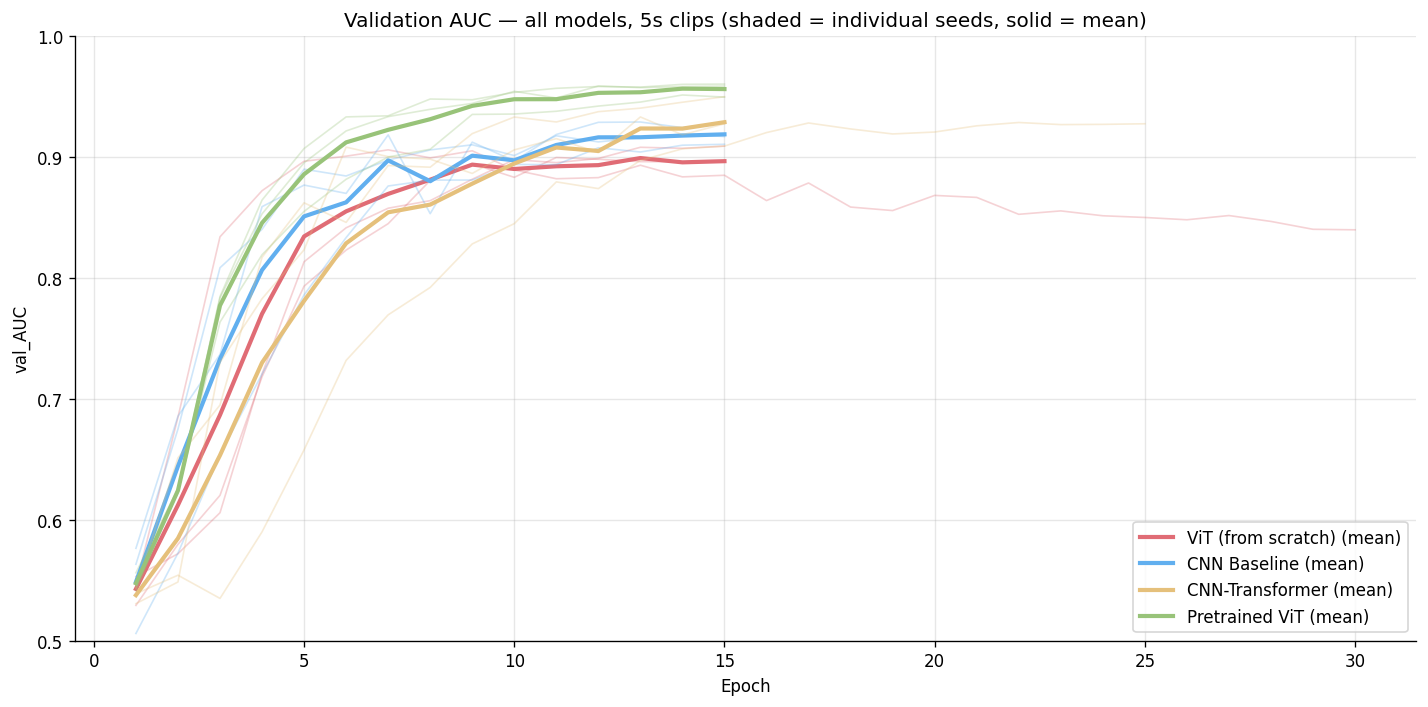

In [4]:
# Group models by architecture for cleaner plots
groups = {
    'ViT (from scratch)':    ['ViT (scratch) s42', 'ViT (scratch) s123', 'ViT (scratch) s456'],
    'CNN Baseline':          ['CNN Baseline s42', 'CNN Baseline s123', 'CNN Baseline s456'],
    'CNN-Transformer':       ['CNN-Transformer s42', 'CNN-Transformer s123', 'CNN-Transformer s456'],
    'Pretrained ViT':        ['Pretrained ViT s42', 'Pretrained ViT s123', 'Pretrained ViT s456'],
}
colors = {
    'ViT (from scratch)': '#e06c75',
    'CNN Baseline':        '#61afef',
    'CNN-Transformer':     '#e5c07b',
    'Pretrained ViT':      '#98c379',
}

fig, ax = plt.subplots(figsize=(12, 6))

for group_name, keys in groups.items():
    color = colors[group_name]
    aucs_per_seed = []
    for key in keys:
        rows = metrics.get(key, [])
        if not rows:
            continue
        epochs = get_field(rows, 'epoch')
        aucs = get_field(rows, 'val_auc')
        ax.plot(epochs, aucs, alpha=0.3, color=color, linewidth=1)
        aucs_per_seed.append(aucs)
    # Plot mean across seeds
    if aucs_per_seed:
        min_len = min(len(a) for a in aucs_per_seed)
        mean_auc = np.mean([a[:min_len] for a in aucs_per_seed], axis=0)
        ax.plot(range(1, min_len + 1), mean_auc, color=color, linewidth=2.5,
                label=f'{group_name} (mean)')

ax.set_xlabel('Epoch')
ax.set_ylabel('val_AUC')
ax.set_title('Validation AUC — all models, 5s clips (shaded = individual seeds, solid = mean)')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_learning_curves_5s.png', dpi=150)
plt.show()

### 1.3 Train loss curves

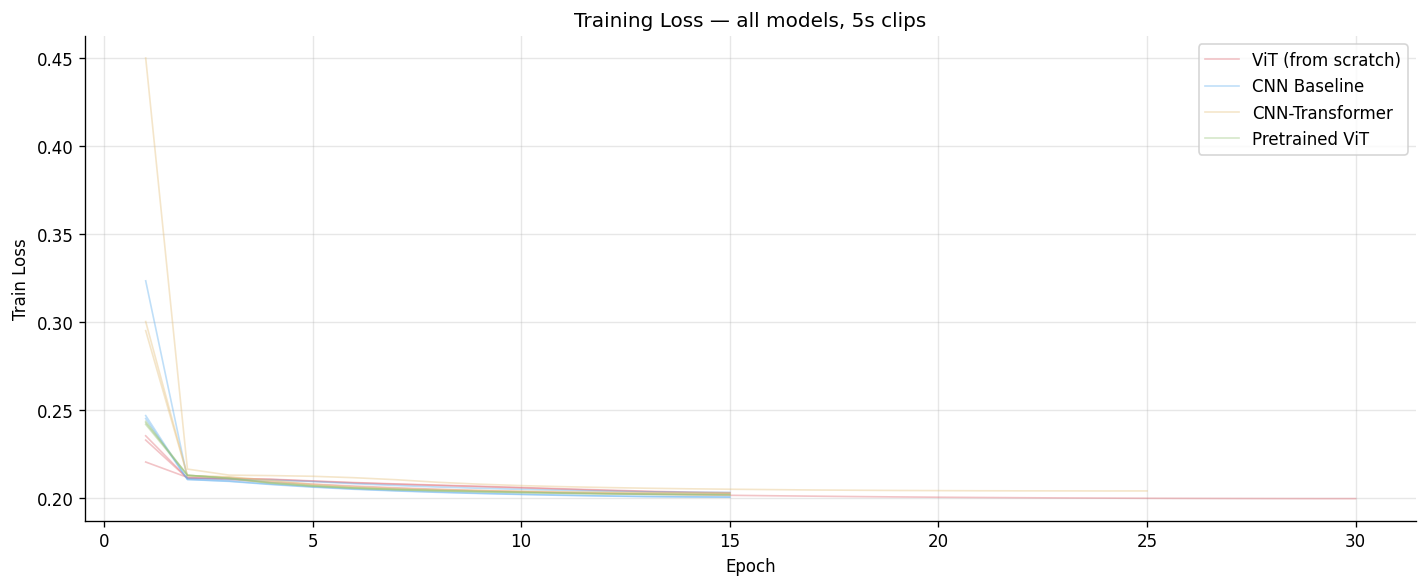

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

for group_name, keys in groups.items():
    color = colors[group_name]
    for key in keys:
        rows = metrics.get(key, [])
        if not rows:
            continue
        epochs = get_field(rows, 'epoch')
        losses = get_field(rows, 'train_loss')
        ax.plot(epochs, losses, alpha=0.4, color=color, linewidth=1,
                label=group_name if key.endswith('s42') else None)

ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss')
ax.set_title('Training Loss — all models, 5s clips')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_train_loss_5s.png', dpi=150)
plt.show()

### 1.4 5s vs 10s clip duration comparison

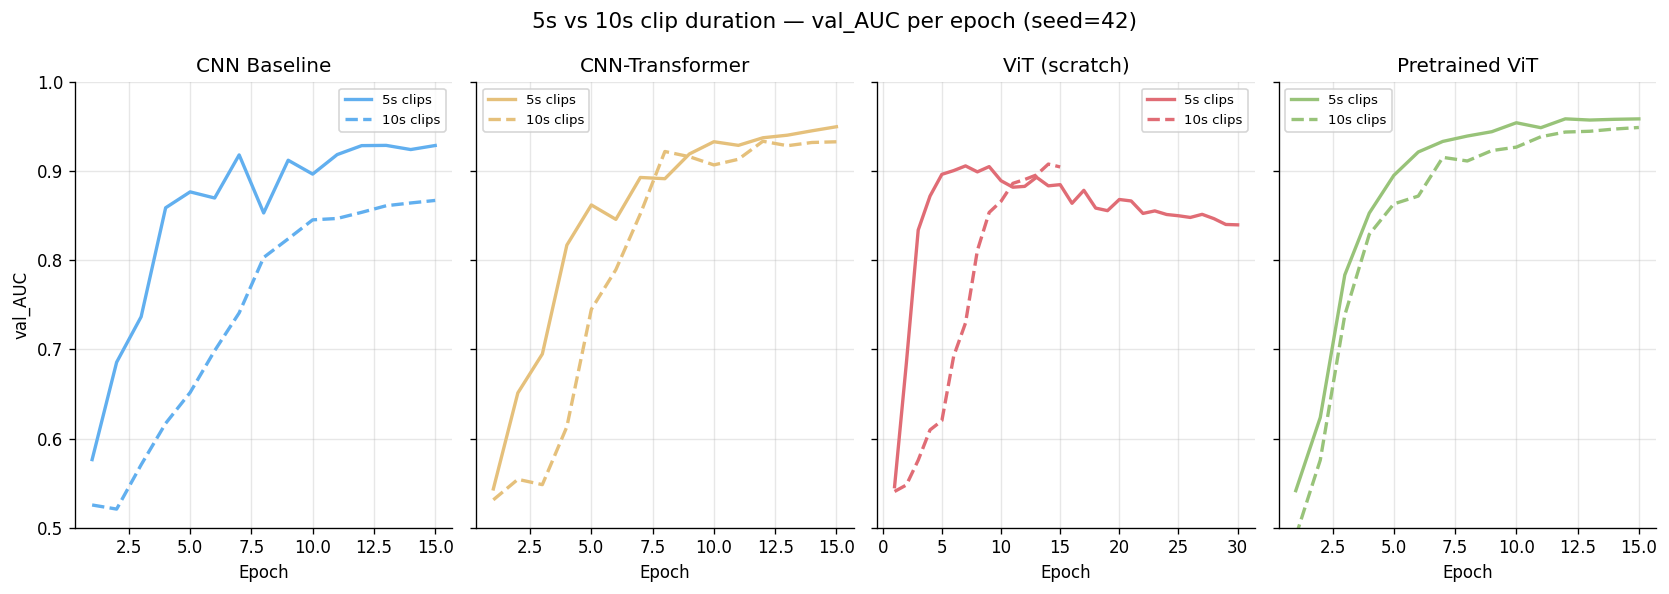

In [6]:
pairs = [
    ('CNN Baseline s42',     'CNN Baseline 10s',    'CNN Baseline',     '#61afef'),
    ('CNN-Transformer s42',  'CNN-Transformer 10s', 'CNN-Transformer',  '#e5c07b'),
    ('ViT (scratch) s42',    'ViT (scratch) 10s',   'ViT (scratch)',    '#e06c75'),
    ('Pretrained ViT s42',   'Pretrained ViT 10s',  'Pretrained ViT',   '#98c379'),
]

fig, axes = plt.subplots(1, len(pairs), figsize=(14, 5), sharey=True)

for ax, (key_5s, key_10s, label, color) in zip(axes, pairs):
    rows_5s  = metrics.get(key_5s, [])
    rows_10s = metrics_10s.get(key_10s, [])
    if rows_5s:
        ax.plot(get_field(rows_5s, 'epoch'), get_field(rows_5s, 'val_auc'),
                color=color, linewidth=2, label='5s clips')
    if rows_10s:
        ax.plot(get_field(rows_10s, 'epoch'), get_field(rows_10s, 'val_auc'),
                color=color, linewidth=2, linestyle='--', label='10s clips')
    ax.set_title(label)
    ax.set_xlabel('Epoch')
    ax.set_ylim(0.5, 1.0)
    ax.legend(fontsize=8)

axes[0].set_ylabel('val_AUC')
fig.suptitle('5s vs 10s clip duration — val_AUC per epoch (seed=42)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_5s_vs_10s.png', dpi=150)
plt.show()

### 1.5 Final val_AUC comparison — bar chart with seed variance

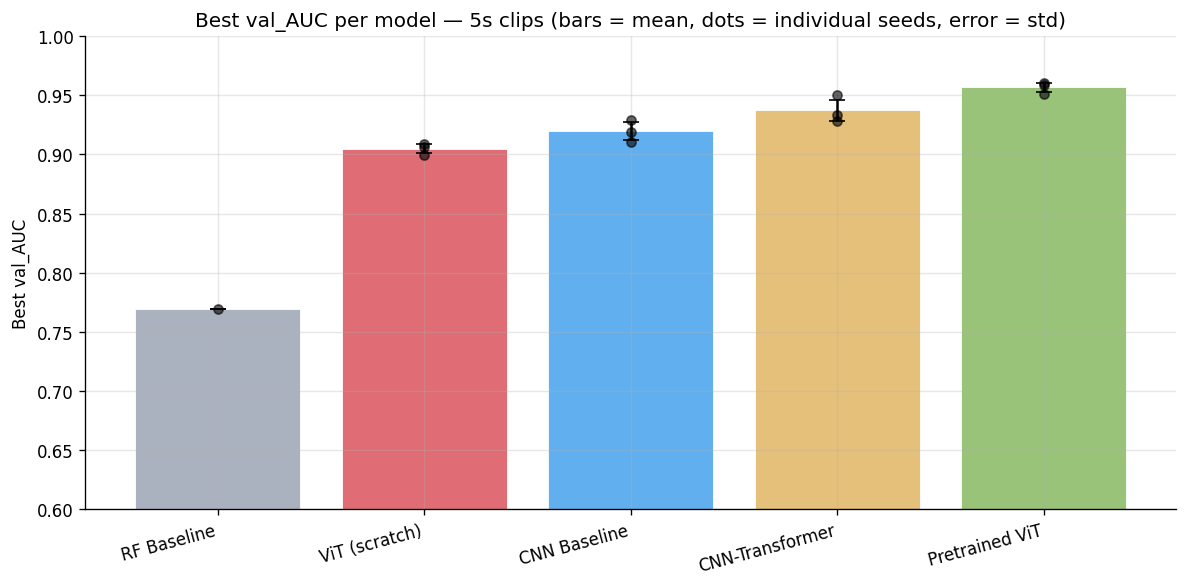

In [7]:
# Best val_AUC per seed (max over epochs)
summary = {
    'RF Baseline':     [0.7690],
    'ViT (scratch)':   [max(get_field(metrics.get(f'ViT (scratch) s{s}', [{}]), 'val_auc', 0)) for s in [42, 123, 456]],
    'CNN Baseline':    [max(get_field(metrics.get(f'CNN Baseline s{s}', [{}]), 'val_auc', 0)) for s in [42, 123, 456]],
    'CNN-Transformer': [max(get_field(metrics.get(f'CNN-Transformer s{s}', [{}]), 'val_auc', 0)) for s in [42, 123, 456]],
    'Pretrained ViT':  [max(get_field(metrics.get(f'Pretrained ViT s{s}', [{}]), 'val_auc', 0)) for s in [42, 123, 456]],
}
# Filter out zeros (missing runs)
summary = {k: [v for v in vals if v > 0] for k, vals in summary.items()}

means = {k: np.mean(v) for k, v in summary.items()}
stds  = {k: np.std(v) if len(v) > 1 else 0 for k, v in summary.items()}

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#abb2bf', '#e06c75', '#61afef', '#e5c07b', '#98c379']
x = np.arange(len(means))
bars = ax.bar(x, means.values(), yerr=stds.values(), capsize=5,
              color=bar_colors, edgecolor='white', linewidth=0.5)

# Overlay individual seed dots
for i, (k, vals) in enumerate(summary.items()):
    ax.scatter([i] * len(vals), vals, color='black', zorder=5, s=30, alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(means.keys(), rotation=15, ha='right')
ax.set_ylabel('Best val_AUC')
ax.set_title('Best val_AUC per model — 5s clips (bars = mean, dots = individual seeds, error = std)')
ax.set_ylim(0.6, 1.0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_model_comparison.png', dpi=150)
plt.show()

---
## 2. Per-class Analysis
### 2.1 Load per-class AUC from checkpoints

In [ ]:
def load_per_class_auc(ckpt_path):
    """Load per-class AUC and class names from a checkpoint."""
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        print(f'  WARNING: {ckpt_path.name} not found.')
        return None, None
    ckpt = torch.load(ckpt_path, map_location='cpu')
    # per_class_auc is saved by evaluate.py; if not present, return None
    per_class = ckpt.get('per_class_auc', None)
    classes   = ckpt.get('classes', None)
    if per_class is None:
        print(f'  WARNING: {ckpt_path.name} has no per_class_auc — run evaluate.py first.')
    return np.array(per_class) if per_class else None, classes

# ── Load checkpoints — adjust filenames to match your actual saved files ──────
checkpoints = {
    'CNN Baseline':    OUTPUT_DIR / 'best_cnn_baseline_seed42.pt',
    'ViT (scratch)':   OUTPUT_DIR / 'best_vit_baseline_seed42.pt',
    'CNN-Transformer': OUTPUT_DIR / 'best_cnn_transformer_seed42.pt',
    'Pretrained ViT':  OUTPUT_DIR / 'best_pretrained_transformer_seed42.pt',
}

per_class_data = {}
class_names = None
for name, path in checkpoints.items():
    auc, classes = load_per_class_auc(path)
    if auc is not None:
        per_class_data[name] = auc
        if class_names is None:
            class_names = classes

print(f'Loaded per-class AUC for: {list(per_class_data.keys())}')
if class_names:
    print(f'K={len(class_names)} species')

### 2.2 Per-class AUC distribution

In [ ]:
if per_class_data:
    fig, ax = plt.subplots(figsize=(10, 5))
    model_colors = ['#61afef', '#e06c75', '#e5c07b', '#98c379']
    for (name, aucs), color in zip(per_class_data.items(), model_colors):
        valid = aucs[~np.isnan(aucs)]
        ax.hist(valid, bins=30, alpha=0.5, color=color, label=f'{name} (mean={valid.mean():.3f})')
    ax.set_xlabel('Per-class AUC')
    ax.set_ylabel('Number of species')
    ax.set_title('Distribution of per-class AUC across all species')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_per_class_auc_dist.png', dpi=150)
    plt.show()
else:
    print('No per-class AUC data available. Run evaluate.py --split val for each model first.')

### 2.3 Hardest and easiest species

In [ ]:
if per_class_data and class_names:
    # Use best model for ranking
    best_model = 'Pretrained ViT' if 'Pretrained ViT' in per_class_data else list(per_class_data.keys())[0]
    aucs = per_class_data[best_model]
    valid_mask = ~np.isnan(aucs)
    valid_aucs = aucs[valid_mask]
    valid_names = np.array(class_names)[valid_mask]

    sorted_idx = np.argsort(valid_aucs)
    N = 15

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Hardest species
    axes[0].barh(valid_names[sorted_idx[:N]], valid_aucs[sorted_idx[:N]], color='#e06c75')
    axes[0].set_xlabel('AUC')
    axes[0].set_title(f'15 Hardest Species ({best_model})')
    axes[0].set_xlim(0, 1)

    # Easiest species
    axes[1].barh(valid_names[sorted_idx[-N:]], valid_aucs[sorted_idx[-N:]], color='#98c379')
    axes[1].set_xlabel('AUC')
    axes[1].set_title(f'15 Easiest Species ({best_model})')
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_hardest_easiest_species.png', dpi=150)
    plt.show()
else:
    print('No per-class AUC data available.')

### 2.4 Per-class AUC — model comparison for hardest species

In [ ]:
if len(per_class_data) > 1 and class_names:
    # Find 20 hardest species for best model
    best_model = 'Pretrained ViT' if 'Pretrained ViT' in per_class_data else list(per_class_data.keys())[0]
    ref_aucs   = per_class_data[best_model]
    valid_mask = ~np.isnan(ref_aucs)
    sorted_idx = np.argsort(ref_aucs[valid_mask])[:20]
    hard_names = np.array(class_names)[valid_mask][sorted_idx]

    fig, ax = plt.subplots(figsize=(12, 7))
    x = np.arange(len(hard_names))
    width = 0.8 / len(per_class_data)
    model_colors = ['#61afef', '#e06c75', '#e5c07b', '#98c379']

    for i, (name, aucs) in enumerate(per_class_data.items()):
        vals = aucs[valid_mask][sorted_idx]
        ax.bar(x + i * width, vals, width, label=name,
               color=model_colors[i % len(model_colors)], alpha=0.85)

    ax.set_xticks(x + width * (len(per_class_data) - 1) / 2)
    ax.set_xticklabels(hard_names, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('AUC')
    ax.set_title('Per-class AUC for 20 hardest species — model comparison')
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_hard_species_comparison.png', dpi=150)
    plt.show()
else:
    print('Need per-class AUC from multiple models for comparison.')

---
## 3. Attention Visualisation
### 3.1 Load model and extract attention weights

In [11]:
from data.preprocessing.data_pipeline import build_dataloaders
from models.registry import load_model

CKPT_PATH = OUTPUT_DIR / 'best_cnn_transformer_final_seed42.pt'

if not CKPT_PATH.exists():
    print(f'Checkpoint not found: {CKPT_PATH}')
else:
    ckpt   = torch.load(CKPT_PATH, map_location='cpu')
    n_cls  = ckpt['num_classes']
    kwargs = ckpt.get('model_kwargs', {})
    model  = load_model('cnn_transformer', n_cls, **kwargs)

    # Strip _orig_mod. prefix added by torch.compile
    state_dict = ckpt['model_state']
    state_dict = {
        k.replace('_orig_mod.', ''): v 
        for k, v in state_dict.items()
    }
    
    model.load_state_dict(state_dict)
    model.eval()
    print(f'Loaded cnn_transformer — K={n_cls}, kwargs={kwargs}')

    # ── Build val loader for example spectrograms ─────────────────────────────
    _, val_loader, _, mlb = build_dataloaders(
        metadata_csv=str(DATA_ROOT / 'train.csv'),
        audio_dir=str(DATA_ROOT / 'train_audio'),
        soundscapes_dir=str(DATA_ROOT / 'train_soundscapes'),
        soundscapes_csv=str(DATA_ROOT / 'train_soundscapes_labels.csv'),
        val_size=0.15, test_size=0.15,
        batch_size=8, num_workers=2, random_state=42,
        duration_cache_path=str(REPO_ROOT / '.cache/birdclef/duration_cache.json'),
        spec_cache_dir='/home/renku/work/kaggle-data/birdclef_specs',
)     
    
    specs_batch, labels_batch = next(iter(val_loader))
    print(f'Example batch: specs={specs_batch.shape}, labels={labels_batch.shape}')

/home/renku/work/aml2026-group-10/models/cnn_transformer.py:110: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Loaded cnn_transformer — K=206, kwargs={'num_cnn_blocks': 4, 'd_model': 256, 'n_layers': 4, 'n_heads': 4, 'dropout': 0.2}
train_audio — recordings: 35549, species: 206
Singleton classes moved to train only: 4 recordings, 4 species
Split — train: 24885 (70%), val: 5332 (15%), test: 5332 (15%)  [seed=42]
Number of classes K: 206
[train] duration cache: 11003 total entries  (hits=0, misses=11003)  -> /home/renku/work/aml2026-group-10/.cache/birdclef/duration_cache.json
[val] duration cache: 11003 existing entries in /home/renku/work/aml2026-group-10/.cache/birdclef/duration_cache.json
[val] duration cache: 13356 total entries  (hits=0, misses=2353)  -> /home/renku/work/aml2026-group-10/.cache/birdclef/duration_cache.json
[test] duration cache: 13356 existing entries in /home/renku/work/aml2026-group-10/.cache/birdclef/duration_cache.json
[test] duration cache: 15709 total entries  (hits=0, misses=2353)  -> /home/renku/work/aml2026-group-10/.cache/birdclef/duration_cache.json
Training samp

/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Example batch: specs=torch.Size([8, 1, 128, 313]), labels=torch.Size([8, 206])


### 3.2 Register attention hooks and run forward pass

In [12]:
if CKPT_PATH.exists():
    attention_maps = []

    def _attn_hook(module, input, output):
        """Hook to capture attention weights from TransformerEncoderLayer.
        nn.TransformerEncoderLayer with batch_first=True returns only the
        hidden states, not attention weights, by default. We monkey-patch
        the self_attn module to capture weights.
        """
        pass  # Handled below via forward_hook on self_attn

    attn_weights_list = []

    def _self_attn_hook(module, input, output):
        # output is (attn_output, attn_weights) when need_weights=True
        if isinstance(output, tuple) and len(output) == 2:
            attn_weights_list.append(output[1].detach())

    hooks = []
    for layer in model.transformer.layers:
        # Force need_weights=True
        original_forward = layer.self_attn.forward
        def make_forward(orig):
            def forward_with_weights(*args, **kwargs):
                kwargs['need_weights'] = True
                kwargs['average_attn_weights'] = True
                return orig(*args, **kwargs)
            return forward_with_weights
        layer.self_attn.forward = make_forward(layer.self_attn.forward)
        h = layer.self_attn.register_forward_hook(_self_attn_hook)
        hooks.append(h)

    with torch.no_grad():
        _ = model(specs_batch)

    for h in hooks:
        h.remove()

    print(f'Captured attention maps from {len(attn_weights_list)} layers')
    if attn_weights_list:
        print(f'Attention shape (layer 0): {attn_weights_list[0].shape}')  # (B, seq_len, seq_len)

Captured attention maps from 4 layers
Attention shape (layer 0): torch.Size([8, 161, 161])


### 3.3 Visualise attention maps on spectrograms

CNN feature map: H=8, W=20, tokens=160 + 1 CLS


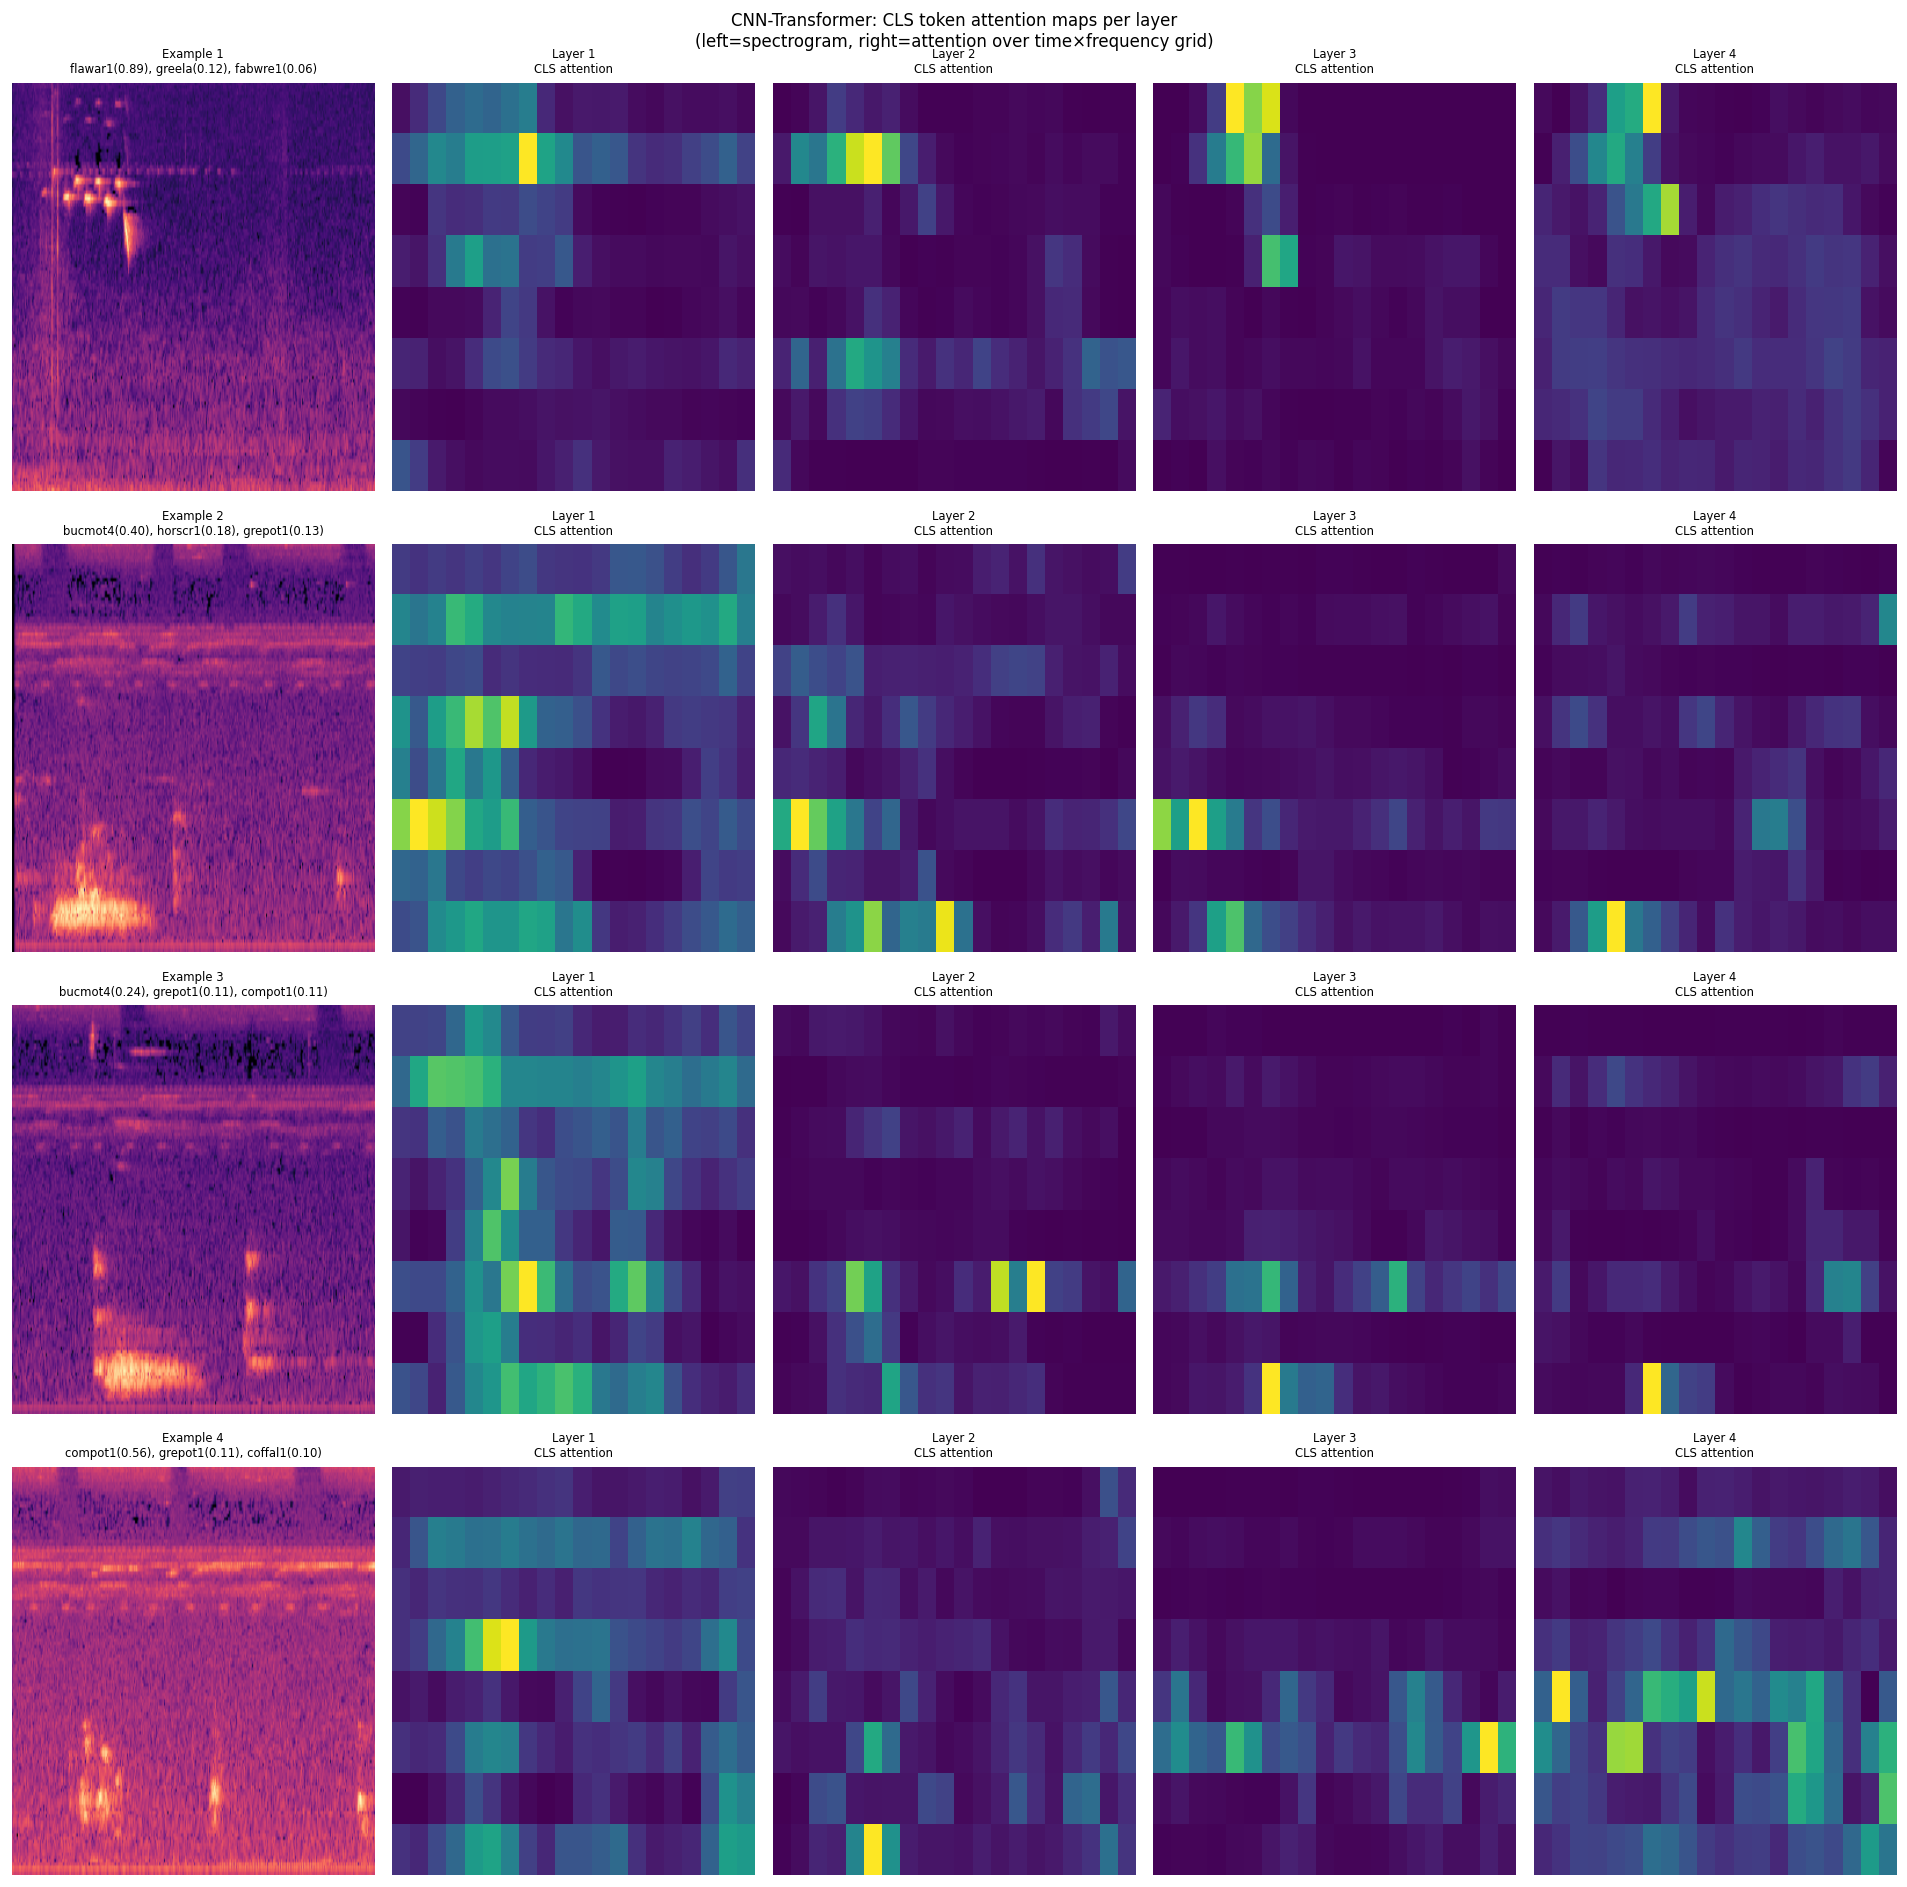

In [13]:
if CKPT_PATH.exists() and attn_weights_list:
    # Get CNN output shape to reconstruct 2D attention grid
    with torch.no_grad():
        dummy = torch.zeros(1, 1, 128, 313)
        feat  = model.cnn(dummy)[0]
    _, _, H, W = feat.shape
    print(f'CNN feature map: H={H}, W={W}, tokens={H*W} + 1 CLS')

    N_EXAMPLES = min(4, specs_batch.shape[0])
    N_LAYERS   = len(attn_weights_list)

    fig = plt.figure(figsize=(16, N_EXAMPLES * 4))
    gs  = gridspec.GridSpec(N_EXAMPLES, N_LAYERS + 1, figure=fig)

    for ex in range(N_EXAMPLES):
        # Plot spectrogram
        ax_spec = fig.add_subplot(gs[ex, 0])
        ax_spec.imshow(specs_batch[ex, 0].numpy(), aspect='auto',
                       origin='lower', cmap='magma')
        # Show predicted species
        with torch.no_grad():
            logits = model(specs_batch[ex:ex+1])
            probs  = torch.sigmoid(logits)[0]
        top3_idx  = probs.topk(3).indices.tolist()
        top3_info = ', '.join([f'{mlb.classes_[i]}({probs[i]:.2f})' for i in top3_idx])
        ax_spec.set_title(f'Example {ex+1}\n{top3_info}', fontsize=7)
        ax_spec.axis('off')

        # Plot attention from CLS token for each layer
        for layer_idx, attn in enumerate(attn_weights_list):
            # attn: (B, seq_len, seq_len); row 0 = CLS attending to all tokens
            cls_attn = attn[ex, 0, 1:].numpy()  # skip CLS self-attention
            attn_2d  = cls_attn.reshape(H, W)
            ax = fig.add_subplot(gs[ex, layer_idx + 1])
            ax.imshow(attn_2d, aspect='auto', origin='lower', cmap='viridis')
            ax.set_title(f'Layer {layer_idx+1}\nCLS attention', fontsize=7)
            ax.axis('off')

    fig.suptitle('CNN-Transformer: CLS token attention maps per layer\n'
                 '(left=spectrogram, right=attention over time×frequency grid)',
                 fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_attention_maps.png', dpi=150)
    plt.show()
else:
    print('Skipped — checkpoint not loaded or no attention weights captured.')

### 3.4 Attention visualisation — Pretrained ViT

In [16]:
import torch.nn.functional as F

CKPT_VIT = OUTPUT_DIR / 'best_pretrained_transformer__final_seed42.pt'

if not CKPT_VIT.exists():
    print(f'Checkpoint not found: {CKPT_VIT}')
else:
    ckpt_vit  = torch.load(CKPT_VIT, map_location='cpu')
    kwargs_vit = ckpt_vit.get('model_kwargs', {})
    vit_model  = load_model('pretrained_transformer', ckpt_vit['num_classes'], **kwargs_vit)

    # Strip _orig_mod. prefix added by torch.compile
    state_dict_vit = ckpt_vit['model_state']
    state_dict_vit = {
        k.replace('_orig_mod.', ''): v 
        for k, v in state_dict_vit.items()
    }
    
    vit_model.load_state_dict(state_dict_vit)
    vit_model.eval()
    print('Loaded pretrained_transformer')

    vit_attn_list = []

    def _vit_attn_hook(module, input, output):
        if isinstance(output, tuple) and len(output) == 2:
            vit_attn_list.append(output[1].detach())

    vit_hooks = []
    for block in vit_model.vit.blocks:
        orig = block.attn.forward
        def make_vit_forward(orig):
            def forward_with_weights(*args, **kwargs):
                return orig(*args, **kwargs)
            return forward_with_weights
        h = block.attn.register_forward_hook(_vit_attn_hook)
        vit_hooks.append(h)

    padded = F.pad(specs_batch, (0, 7))  # pad to 320
    with torch.no_grad():
        _ = vit_model.vit(padded)

    for h in vit_hooks:
        h.remove()

    print(f'Captured {len(vit_attn_list)} attention layers from pretrained ViT')
    if vit_attn_list:
        print(f'Attention shape (layer 0): {vit_attn_list[0].shape}')  # (B, n_heads, seq_len, seq_len)

Loaded pretrained_transformer
Captured 0 attention layers from pretrained ViT


In [17]:
if CKPT_VIT.exists() and vit_attn_list:
    # ViT-Small/16 on (128, 320): patch grid = 8×20 = 160 tokens
    H_vit, W_vit = 8, 20
    # Show last 4 layers (most task-relevant)
    layers_to_show = vit_attn_list[-4:]
    N_EXAMPLES = min(3, specs_batch.shape[0])

    fig, axes = plt.subplots(N_EXAMPLES, len(layers_to_show) + 1,
                             figsize=(16, N_EXAMPLES * 3.5))
    if N_EXAMPLES == 1:
        axes = axes[np.newaxis, :]

    for ex in range(N_EXAMPLES):
        axes[ex, 0].imshow(specs_batch[ex, 0].numpy(),
                           aspect='auto', origin='lower', cmap='magma')
        axes[ex, 0].set_title(f'Example {ex+1}\nSpectrogram', fontsize=8)
        axes[ex, 0].axis('off')

        for li, attn in enumerate(layers_to_show):
            # attn: (B, n_heads, seq_len, seq_len)
            # Average heads, take CLS row, skip CLS self-attention
            cls_attn = attn[ex].mean(0)[0, 1:].numpy()
            attn_2d  = cls_attn[:H_vit * W_vit].reshape(H_vit, W_vit)
            axes[ex, li + 1].imshow(attn_2d, aspect='auto',
                                     origin='lower', cmap='viridis')
            layer_num = len(vit_attn_list) - len(layers_to_show) + li + 1
            axes[ex, li + 1].set_title(f'Layer {layer_num}\nCLS attn (mean heads)', fontsize=8)
            axes[ex, li + 1].axis('off')

    fig.suptitle('Pretrained ViT: CLS token attention maps (last 4 layers, mean over heads)',
                 fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_vit_attention_maps.png', dpi=150)
    plt.show()
else:
    print('Skipped — checkpoint not loaded or no attention weights captured.')

Skipped — checkpoint not loaded or no attention weights captured.


---
## Summary of saved figures

| File | Contents |
|---|---|
| `fig_learning_curves_5s.png` | val_AUC per epoch, all models, 3 seeds |
| `fig_train_loss_5s.png` | Train loss per epoch, all models |
| `fig_5s_vs_10s.png` | 5s vs 10s val_AUC per epoch, per model |
| `fig_model_comparison.png` | Bar chart — best val_AUC with seed variance |
| `fig_per_class_auc_dist.png` | Histogram of per-class AUC across species |
| `fig_hardest_easiest_species.png` | 15 hardest and easiest species by AUC |
| `fig_hard_species_comparison.png` | Per-class AUC for hardest species across models |
| `fig_attention_maps.png` | CNN-Transformer CLS attention maps |
| `fig_vit_attention_maps.png` | Pretrained ViT CLS attention maps |